<a href="https://colab.research.google.com/github/IsabelaBersan/tech-challenge-fase2/blob/main/notebooks/03_modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 6. Separação dos dados


### 6.1 Utilizando todas as features

In [ ]:
x = df.drop(columns = ['quality_binary', 'quality'])
y = df['quality_binary'] # o que eu quero prever. (target)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

### 6.2 Utilizando features mais correlacionadas

In [ ]:
x_corr = df[['alcohol', 'volatile acidity','sulphates','citric acid']]
y_corr = df['quality_binary'] # o que eu quero prever. (target)

In [ ]:
x_train_corr, x_test_corr, y_train_corr, y_test_corr = train_test_split(x_corr, y, test_size=0.2, stratify=y, random_state=42)


## 7. Normalizando os dados

Normalizando todas as variáveis

In [ ]:
#Normalizar apenas com os dados de treino para não ocorrer vazamento de dados e colocado "FIT" para os dados de test pelo mesmo motivo
scaler = StandardScaler()
scaler.fit(x_train)
x_train_escalonado = scaler.transform(x_train) # X_TRAIN → Aprende + Transforma. O scaler "estuda" a média e desvio padrão do X_train
x_test_escalonado = scaler.transform(x_test) # X_TEST → Só Transforma. O scaler usa os parâmetros que APRENDEU do X_train

Normalizando váriaveis correlacionadas

In [ ]:
#Normalizar apenas com os dados de treino para não ocorrer vazamento de dados e colocado "FIT" para os dados de test pelo mesmo motivo
scaler = StandardScaler()
scaler.fit(x_train_corr)
x_train_escalonado_corr = scaler.transform(x_train_corr) # X_TRAIN → Aprende + Transforma. O scaler "estuda" a média e desvio padrão do X_train
x_test_escalonado_corr = scaler.transform(x_test_corr) # X_TEST → Só Transforma. O scaler usa os parâmetros que APRENDEU do X_train

## 8. MODELO DE MACHINE LEARNING

### 8.1 KNN


### 8.1.1 Criando Modelo - 11 Variáveis

Text(0, 0.5, 'Mean Error')

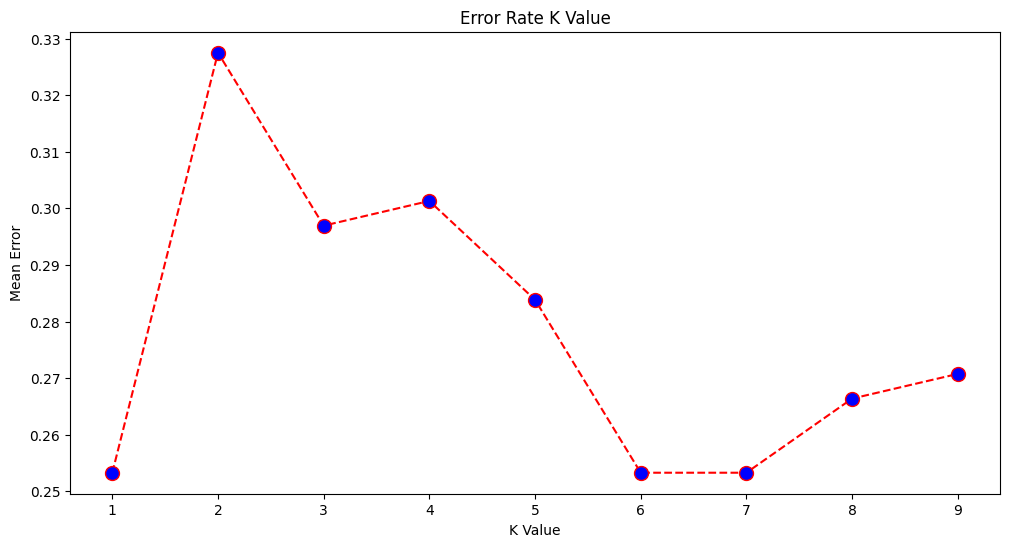

In [ ]:
#Melhorando Hiperparâmetros
error = []

# Calculating error for K values between 1 and 10
for i in range(1, 10): #range de tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i)# aqui definimos  o k
    knn.fit(x_train_escalonado, y_train) #treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_escalonado) #armazenando as previsões
    error.append(np.mean(pred_i != y_test)) #armazenando o valor do erro médio na lista de erros


plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [ ]:
# Vamos usar uma técnica chamada Gridsearch que é basicamente a busca por força bruta
# Iremos utilizar a técnica de validação cruzada de 5 folds (divisões) em cima do conjunto de treinamento
# Como métrica de melhor desemepnho usaremos a acurácia, isto é, estamos buscando os hiperparâmetros que maximizam a acurácia

from sklearn.model_selection import GridSearchCV #metodo para seleção dos melhores Ks (#Basicamente a busca por força bruta)
from sklearn.metrics import make_scorer, accuracy_score, f1_score #métricas de validação
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros testados
param_grid = {'n_neighbors':[6,7,8,9], #total de vizinhos
              'weights': ['uniform', 'distance'], #Função de peso usada na previsão
              'metric':['cosine', 'euclidean', 'manhattan'] #métrica para cálculo da distância
             }

# Métrica de desempenho = melhor acurácia
gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid,
                    scoring=gs_metric,
                    cv=5, n_jobs=4, verbose=3) #cv = gerador de validação cruzada / n_jobs = determina a quantidade de jobs processados

grid.fit(x_train_escalonado, y_train) #Selecionando os melhores hiperparametros com base nos dados de treino
knn_params = grid.best_params_
print('KNN', knn_params)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN {'metric': 'cosine', 'n_neighbors': 9, 'weights': 'distance'}


In [ ]:
knn = KNeighborsClassifier(n_neighbors=9, metric='cosine', weights='distance') # utilizado o parametro de grid como melhor hiperparametro
knn.fit(x_train_escalonado, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=9, weights='distance')

In [ ]:
#prever
y_pred = knn.predict(x_test_escalonado)

In [ ]:
#Avaliar
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.7860262008733624


### 8.1.4 Criando modelo com 4 váriavies mais correlacionadas


In [ ]:
#Melhorando Hiperparâmetros
error = []

# Calculating error for K values between 1 and 10
for i in range(1, 10): #range de tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i)# aqui definimos  o k
    knn.fit(x_train_escalonado_corr, y_train_corr) #treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_escalonado_corr) #armazenando as previsões
    error.append(np.mean(pred_i != y_test)) #armazenando o valor do erro médio na lista de erros


plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

NameError: name 'KNeighborsClassifier' is not defined

In [ ]:


param_grid_corr = {'n_neighbors':[7,8,9], #total de vizinhos
              'weights': ['uniform', 'distance'], #Função de peso usada na previsão
              'metric':['cosine', 'euclidean', 'manhattan'] #métrica para cálculo da distância
             }

# Métrica de desempenho = melhor acurácia
gs_metric_corr = make_scorer(accuracy_score, greater_is_better=True)

grid_corr = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid_corr,
                    scoring=gs_metric_corr,
                    cv=5, n_jobs=4, verbose=3) #cv = gerador de validação cruzada / n_jobs = determina a quantidade de jobs processados

grid_corr.fit(x_train_escalonado_corr, y_train_corr) #Selecionando os melhores hiperparametros com base nos dados de treino
knn_params_corr = grid_corr.best_params_
print('KNN', knn_params_corr)

In [ ]:
knn_corr = KNeighborsClassifier(n_neighbors=9, metric='manhattan', weights='distance') # utilizado o parametro de grid como melhor hiperparametro
knn_corr.fit(x_train_escalonado_corr, y_train_corr)

In [ ]:
y_pred_corr = knn_corr.predict(x_test_escalonado_corr)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test_corr, y_pred_corr)}")

### 8.1.5 Curva ROC 4 váriavies mais correlacionadas

AUC: 0.8725


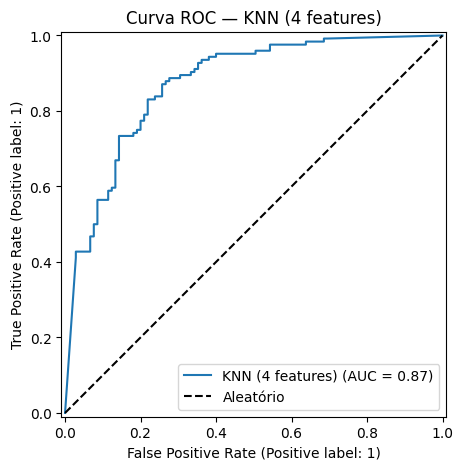

In [ ]:
# Criando curva ROC — 4 features

y_score_knn_corr = knn_corr.predict_proba(x_test_escalonado_corr)[:, 1]
print(f"AUC: {roc_auc_score(y_test_corr, y_score_knn_corr):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_corr, y_score_knn_corr,
                                 name='KNN (4 features)', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório')
ax.set_title('Curva ROC — KNN (4 features)')
ax.legend()
plt.show()

### 8.2 SVM

### 8.2.1 Criando Modelo com 11 variáveis

In [ ]:
#Melhorando Hiperparametro
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm,
                        scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_svm.fit(x_train_escalonado, y_train)
print('SVM:', grid_svm.best_params_)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
#resultado
svm = grid_svm.best_estimator_
y_pred_svm = svm.predict(x_test_escalonado)
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")


Acurácia: 0.7860


### 8.2.2 Curva ROC - 11 variáveis

AUC: 0.8415


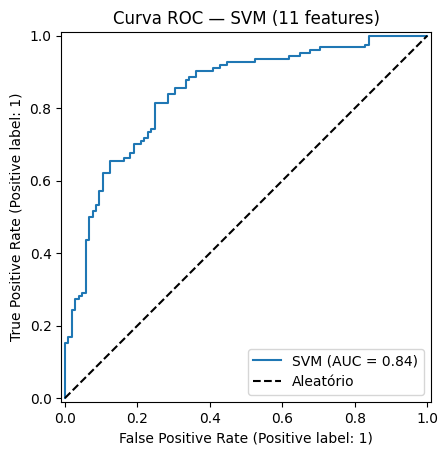

In [ ]:
# Curva ROC
y_score_svm = svm.decision_function(x_test_escalonado)
print(f"AUC: {roc_auc_score(y_test, y_score_svm):.4f}")

RocCurveDisplay.from_predictions(y_test, y_score_svm, name='SVM')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.title('Curva ROC — SVM (11 features)')
plt.legend()
plt.show()

### 8.2.4 Criando Modelo com 4 variáveis mais correlacionadas

In [ ]:
#Melhorando Hiperparametro
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
param_grid_svm_corr = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm_corr = GridSearchCV(SVC(random_state=42), param_grid_svm_corr,
                        scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_svm_corr.fit(x_train_escalonado_corr, y_train_corr)
print('SVM:', grid_svm_corr.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
#resultado
svm_corr = grid_svm_corr.best_estimator_
y_pred_svm_corr = svm_corr.predict(x_test_escalonado_corr)
print(f"Acurácia: {accuracy_score(y_test_corr, y_pred_svm_corr):.4f}")

Acurácia: 0.7773


### 8.2.6 Curva ROC 4 variáveis mais correlacionadas

AUC: 0.8379


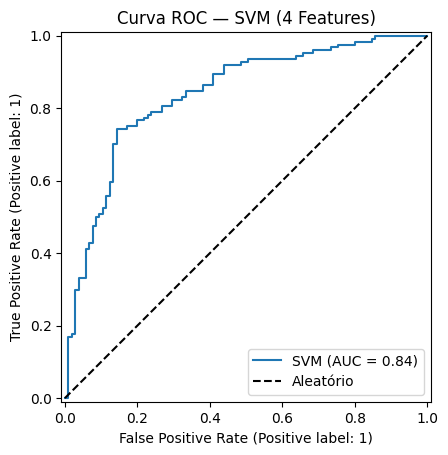

In [ ]:

y_score_svm_corr = svm_corr.decision_function(x_test_escalonado_corr)
print(f"AUC: {roc_auc_score(y_test_corr, y_score_svm_corr):.4f}")

RocCurveDisplay.from_predictions(y_test_corr, y_score_svm_corr, name='SVM')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.title('Curva ROC — SVM (4 Features)')
plt.legend()
plt.show()

### 9 Comparação entre as avaliações

Cada modelo foi avaliado isoladamente nas seções anteriores. Aqui os quatro cenários
(KNN e SVM, cada um com as 11 variáveis físico-químicas e com as 4 de maior correlação)
são reunidos em um único quadro comparativo, usando as previsões já geradas nenhummodelo é retreinado nesta seção.

As métricas utilizadas são:

- **Acurácia:** percentual total de acertos. Comparada com a baseline (classificar todos os
  vinhos como "bom"), que acerta 54,2% no conjunto de teste.
- **Precisão:** entre os vinhos que o modelo aprovou, quantos eram realmente bons. Métrica
  crítica quando o custo de aprovar um vinho ruim é alto (risco de reputação).
- **Recall:** entre os vinhos realmente bons, quantos o modelo conseguiu identificar. Métrica
  crítica quando o custo é deixar de aproveitar um bom lote.
- **F1:** média harmônica entre precisão e recall.
- **AUC:** capacidade de ordenar corretamente os vinhos por qualidade, considerando todos os
  limiares de decisão possíveis (independe do corte padrão de 0,5).
- **FP / FN:** erros absolutos — vinhos regulares aprovados como bons (falso positivo) e vinhos
  bons reprovados como regulares (falso negativo).

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import pandas as pd

# Reaproveita as previsões e os scores já calculados nas seções 8.1 e 8.2
resultados = {
    'KNN (11 features)': (y_test,      y_pred,          y_score_knn),
    'KNN (4 features)':  (y_test_corr, y_pred_corr,     y_score_knn_corr),
    'SVM (11 features)': (y_test,      y_pred_svm,      y_score_svm),
    'SVM (4 features)':  (y_test_corr, y_pred_svm_corr, y_score_svm_corr),
}

linhas = []
for nome, (y_true, y_hat, y_score) in resultados.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    linhas.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_true, y_hat),
        'Precisão': precision_score(y_true, y_hat),
        'Recall': recall_score(y_true, y_hat),
        'F1': f1_score(y_true, y_hat),
        'AUC': roc_auc_score(y_true, y_score),
        'FP (aprovou errado)': fp,
        'FN (reprovou errado)': fn,
    })

comparativo = pd.DataFrame(linhas).set_index('Modelo').round(4)

baseline = y_test.mean()
print(f"Baseline (classificar todos os vinhos como 'bom'): {baseline:.4f}")
comparativo

Baseline (classificar todos os vinhos como 'bom'): 0.5415


,Acurácia,Precisão,Recall,F1,AUC,FP (aprovou errado),FN (reprovou errado)
Modelo,,,,,,,
KNN (11 features),0.7860,0.7863,0.8306,0.8078,0.8565,28,21
KNN (4 features),0.8035,0.7970,0.8548,0.8249,0.8725,27,18
SVM (11 features),0.7860,0.7953,0.8145,0.8048,0.8415,26,23
SVM (4 features),0.7773,0.8017,0.7823,0.7918,0.8379,24,27


##9.1 Escolha dos algoritmos: KNN e SVM


> Optamos por algoritmos de **famílias distintas de aprendizado**, para que a comparação seja informativa e não apenas uma variação do mesmo princípio.
>
> **KNN (baseado em instâncias).** Classifica cada vinho pela semelhança físico-química com as amostras já avaliadas. É o algoritmo que mais se aproxima do raciocínio real deprofissional cientista e técnico responsável por toda a criação e produção do vinho , o que facilita a comunicação do modelo à área de negócio.
>
> **SVM com kernel RBF (margem máxima).** Constrói uma fronteira global orientada pelos casos de difícil separação, os vinhos de qualidade intermediária que também são os mais difíceis para o painel sensorial.
>
> **Complementaridade.** O KNN decide **localmente** (vizinhança) e o SVM decide **globalmente** (uma única fronteira). Se dois princípios tão diferentes chegam a desempenhos próximos, isso indica que o teto está nos dados e não na escolha do algoritmo. Ambos são sensíveis à escala, o que dá coerência à etapa de padronização.
>
> **Adequação ao tamanho da base.** Com 1.143 amostras e 11 variáveis, os dois operam em faixa confortável: há vizinhos suficientes para o KNN e o custo quadrático do SVM é irrelevante nesta escala.

#### 9.2 Conclusões da comparação

**Desempenho geral.** Os quatro cenários ficam entre 77,7% e 80,3% de acurácia e entre
0,838 e 0,873 de AUC, acima da baseline de 54,1%, mas próximos entre si. A
diferença entre o melhor e o pior modelo é de 2,6 pontos percentuais de acurácia, o que
equivale a 6 vinhos em 229 no conjunto de teste: uma vantagem pequena demais para ser
considerada decisiva com uma única divisão treino/teste.

**KNN x SVM.** O melhor resultado global é do **KNN com 4 variáveis** (acurácia 80,3%,
AUC 0,873, F1 0,825), superior a todos os cenários do SVM em todas as métricas agregadas.
Com as 11 variáveis, os dois algoritmos empatam em acurácia (78,6%), mas o KNN mantém AUC
superior (0,857 contra 0,842). Ou seja: o KNN se beneficia da redução de variáveis, enquanto
o SVM piora levemente (78,6% para 77,7%) comportamento coerente, já que o KNN sofre mais
com o efeito da dimensionalidade no cálculo de distâncias, enquanto o kernel RBF do SVM já
absorve variáveis pouco informativas.

**Perfil de erro — a diferença mais relevante.** As duas famílias erram de formas opostas:

- O **KNN é permissivo**: no cenário de 4 variáveis, aprovou 27 vinhos regulares como bons
  (falsos positivos) e reprovou apenas 18 vinhos bons. É o modelo de maior recall (85,5%) —
  deixa passar poucos bons lotes.
- O **SVM é conservador**: no mesmo cenário, é o que menos aprova errado (24 falsos positivos),
  atingindo a maior precisão do conjunto (80,2%), mas ao custo de reprovar 27 vinhos bons —
  o pior recall (78,2%).
